### [Financial Data Analysis: Understanding Risk vs. Return](https://medium.com/@simplifiedzone/master-financial-data-analysis-understanding-risk-vs-return-e8ecb76ae0fa)

In [1]:
!pip install -q yfinance

In [2]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

# Define the date range for the last 5 years
start = datetime.date(2016, 11, 16)
end = datetime.date(2021, 11, 19)
df = yf.download(["AMZN", "F", "BTC-USD"], start, end, progress=False)["Close"]

# Take a look at the first few rows
display(df.sample(10))

/tmp/ipython-input-3958033298.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(["AMZN", "F", "BTC-USD"], start, end, progress=False)["Close"]


Ticker,AMZN,BTC-USD,F
Date,,,
2021-10-25,166.018494,63039.824219,12.140022
2017-08-27,NaN,4382.879883,NaN
2018-06-08,84.199501,7624.919922,8.200665
2019-05-09,94.993500,6174.528809,7.376871
2018-10-26,82.140503,6474.750000,6.282541
2019-10-18,87.875504,7973.207520,6.819016
2021-07-27,181.319504,39406.941406,10.463182
2018-10-09,93.515999,6642.640137,6.151055
2018-05-17,79.087997,8094.319824,7.766912


In [3]:
# Get summary statistics of the price data
display(df.describe())

Ticker,AMZN,BTC-USD,F
count,1261.000000,1829.000000,1261.000000
mean,101.126327,14288.494413,7.313716
std,43.754087,16166.619474,1.813912
min,37.016998,731.026001,3.042593
25%,71.352501,4610.479980,6.416145
50%,90.648499,8269.809570,7.090779
75%,153.904999,11790.916992,7.875760
max,186.570496,67566.828125,15.288839


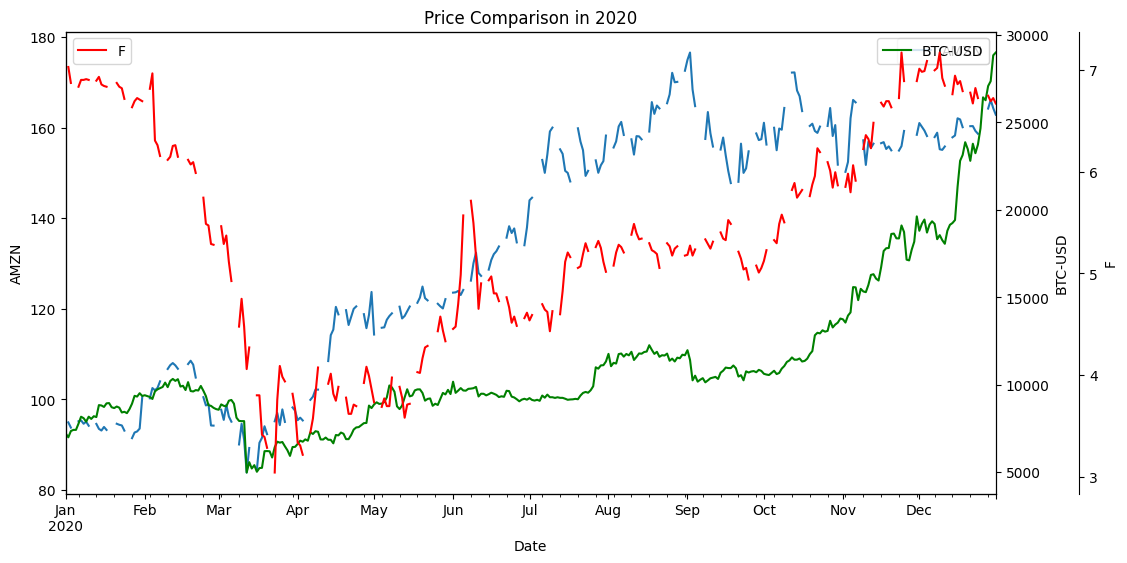

In [4]:
# Create a figure with a shared index but different y-axis scales
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Plot the 2020 price data for each asset
df["2020-01-01":"2020-12-31"].plot(ax=ax1, y="AMZN", legend=True)
df["2020-01-01":"2020-12-31"].plot(ax=ax2, y="BTC-USD", legend=True, color="g")
df["2020-01-01":"2020-12-31"].plot(ax=ax3, y="F", legend=True, color="r")

# Set the labels for the axes
ax1.set_ylabel("AMZN")
ax2.set_ylabel("BTC-USD")
ax3.set_ylabel("F")
ax3.spines["right"].set_position(("outward", 60))
plt.title("Price Comparison in 2020")
plt.show()

In [5]:
# Pull 10 years of daily price data
start_indices = datetime.date(2015, 11, 25)
end_indices = datetime.date.today()

prices_indices = yf.download(["^GSPC", "^RUT"], start_indices, end_indices)["Close"]
prices_indices = prices_indices.rename(columns={"^GSPC": "SP500", "^RUT": "Russell2000"})

display(prices_indices.head())

/tmp/ipython-input-948709288.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices_indices = yf.download(["^GSPC", "^RUT"], start_indices, end_indices)["Close"]
[*********************100%***********************]  2 of 2 completed


Ticker,SP500,Russell2000
Date,,
2015-11-25,2088.870117,1198.020020
2015-11-27,2090.110107,1202.380005
2015-11-30,2080.409912,1198.109985
2015-12-01,2102.629883,1204.160034
2015-12-02,2079.510010,1191.689941


In [6]:
# Calculate the high-low range for the last year of data
currYear = prices_indices.loc[datetime.date.today() - datetime.timedelta(365) : datetime.date.today()]
high_low_range = currYear.max() - currYear.min()
display(high_low_range)

,0
Ticker,
SP500,1927.020020
Russell2000,829.900146


In [7]:
# Standardize by dividing by the current price
standardized_high_low = high_low_range / prices_indices.iloc[-1]
display(standardized_high_low)

,0
Ticker,
SP500,0.278883
Russell2000,0.326588


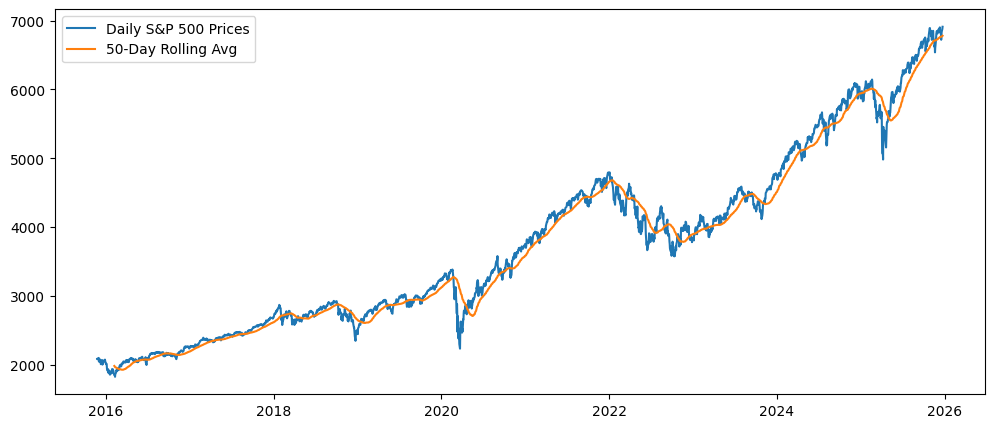

In [8]:
# Calculate and plot the 50-day moving average for the S&P 500
prices_indices["SP500_50_day_rolling_avg"] = prices_indices.SP500.rolling(50).mean()

plt.figure(figsize=(12, 5))
plt.plot(prices_indices["SP500"], label="Daily S&P 500 Prices")
plt.plot(prices_indices["SP500_50_day_rolling_avg"], label="50-Day Rolling Avg")
plt.legend()
plt.show()

In [9]:
# Moving average volatility
ma_volatility = ((abs(prices_indices - prices_indices.rolling(50).mean())) / prices_indices).mean()
display(ma_volatility)

,0
Ticker,
SP500,0.030876
Russell2000,0.040290
SP500_50_day_rolling_avg,0.023623


In [10]:
# Calculate log returns
log_returns_indices = np.log(prices_indices) - np.log(prices_indices.shift(1))
log_returns_indices = log_returns_indices.dropna()

# Calculate the standard deviation of daily returns
std_dev_returns = log_returns_indices.std()
display(std_dev_returns)

,0
Ticker,
SP500,0.011426
Russell2000,0.014824
SP500_50_day_rolling_avg,0.001284


In [11]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yfin

def investCompare(startTime, endTime, tickers):
    # Pull price data
    prices = yfin.download(list(tickers.keys()), startTime, endTime)["Close"]
    prices = prices.rename(columns=tickers)

    # Calculate log returns
    returns = np.log(prices) - np.log(prices.shift(1))
    returns = returns.iloc[1:, 0:]

    # Calculate High-Low volatility for the last year
    currYear = prices.loc[datetime.date.today() - datetime.timedelta(365) : datetime.date.today()]
    highLow = (currYear.max() - currYear.min()) / prices.iloc[-1]
    highLow = pd.DataFrame(highLow, columns=["HighMinusLow"])

    # Moving average volatility
    MA = pd.DataFrame(
        ((abs(prices - prices.rolling(50).mean())) / prices).mean(),
        columns=["MovingAverageVolatility"],
    )

    # Combine metrics into a single DataFrame
    investments = pd.merge(highLow, MA, left_index=True, right_index=True)
    investments = pd.merge(
        investments,
        pd.DataFrame(returns.std(), columns=["StandardDeviation"]),
        left_index=True,
        right_index=True,
    )
    investments = pd.merge(
        investments,
        pd.DataFrame(100 * returns.mean(), columns=["Daily Return Percentage"]),
        left_index=True,
        right_index=True,
    )

    return investments.round(3)

# Example usage: Growth vs. Value ETFs
display(investCompare(
    datetime.date(2010, 1, 1), datetime.date.today(), {"VUG": "Growth", "VTV": "Value"}
))

/tmp/ipython-input-2375521414.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yfin.download(list(tickers.keys()), startTime, endTime)["Close"]
[*********************100%***********************]  2 of 2 completed


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
Value,0.213,0.027,0.010,0.044
Growth,0.355,0.035,0.012,0.059
